In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
sys.path.append(os.path.abspath(os.path.join("..")))

from source.transform_data import add_features

In [17]:
hour_data = pd.read_csv("../data/raw/hour.csv")
#day_data = pd.read_csv("../data/raw/day.csv")

In [18]:
print("Rows:", len(hour_data))
print("Columns:", len(hour_data.columns))

hour_data.head()

Rows: 17379
Columns: 17


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [19]:
hour_data["dteday"] = pd.to_datetime(hour_data["dteday"])
hour_data["dteday"].dt.year
print(hour_data["dteday"].min())
print(hour_data["dteday"].max())

2011-01-01 00:00:00
2012-12-31 00:00:00


In [20]:
hour_data.dtypes

instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

In [21]:
hour_features=add_features(hour_data)
hour_features[["hr", "workingday", "cnt", "time_of_day", "high_demand", "rush_hour"]].head(20)

,hr,workingday,cnt,time_of_day,high_demand,rush_hour
0,0,0,16,Night,0,0
1,1,0,40,Night,0,0
2,2,0,32,Night,0,0
3,3,0,13,Night,0,0
4,4,0,1,Night,0,0
5,5,0,1,Morning,0,0
6,6,0,2,Morning,0,0
7,7,0,3,Morning,0,0
8,8,0,8,Morning,0,0
9,9,0,14,Morning,0,0


time_of_day
Morning      5077
Night        5015
Afternoon    3645
Evening      3642
Name: count, dtype: int64


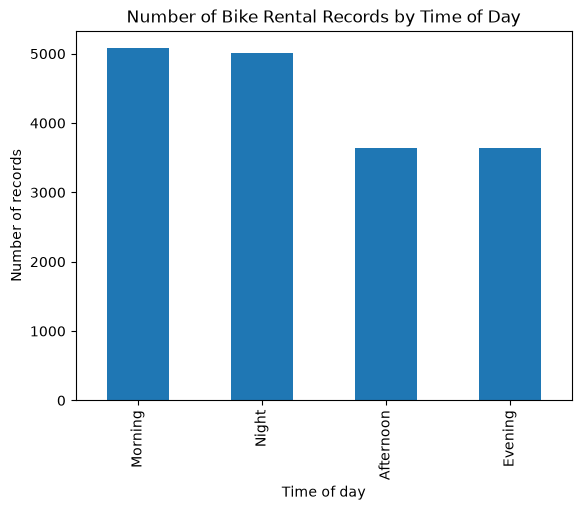

In [ ]:
time_counts=hour_features["time_of_day"].value_counts()
print(time_counts)

time_counts.plot(kind="bar")
plt.xlabel("Time of day")
plt.ylabel("Number of records")
plt.title("Number of Bike Rental Records by Time of Day")
plt.show()

It is seen from bar chart that people use rental the most in the morning and evening. It reaches around 5000 records.

In [23]:
time_demand = hour_features.groupby("time_of_day")["cnt"].mean()
print(time_demand)

time_of_day
Afternoon    262.244719
Evening      319.444261
Morning      181.520583
Night         50.209571
Name: cnt, dtype: float64


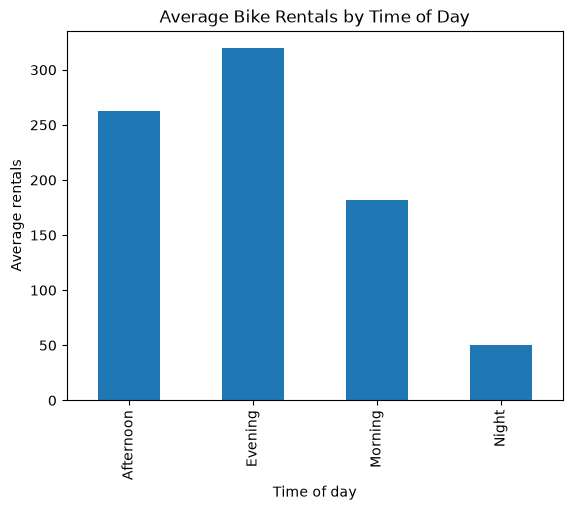

In [24]:
time_demand.plot(kind="bar")
plt.xlabel("Time of day")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals by Time of Day")
plt.show()

In the evening the demand is the highest, at night the lowest one. 

In [25]:
print(hour_features["high_demand"].value_counts())

demand_median = hour_features["cnt"].median()
print("Median rentals:", demand_median)

high_demand
0    8708
1    8671
Name: count, dtype: int64
Median rentals: 142.0


In [26]:
print(hour_features["rush_hour"].value_counts())
rush_demand = hour_features.groupby("rush_hour")["cnt"].mean()
print(rush_demand)

rush_hour
0    14396
1     2983
Name: count, dtype: int64
rush_hour
0    146.665324
1    396.005699
Name: cnt, dtype: float64


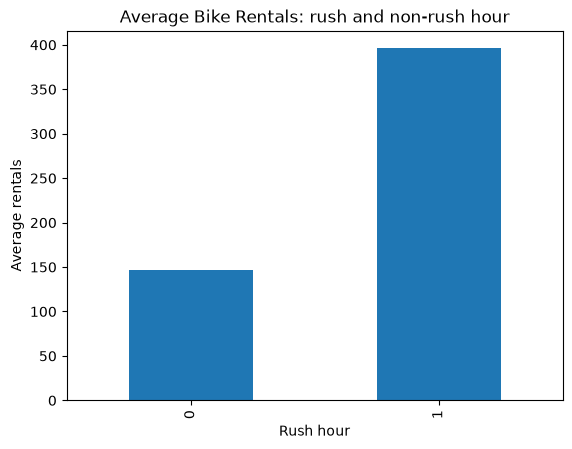

In [31]:
rush_demand.plot(kind="bar")
plt.xlabel("Rush hour")
plt.ylabel("Average rentals")
plt.title("Average Bike Rentals: rush and non-rush hour")
plt.show()

0 means that it is not rush hours, 1 means working days and time between 7 and 9, 17 and 19, and it is observed that quite bigger amount of people utilize bike rental service.

In [28]:
# .size how many rows in each group
workingday_demand = (hour_features.groupby(["workingday", "high_demand"]).size())
print(workingday_demand)

workingday  high_demand
0           0              3009
            1              2505
1           0              5699
            1              6166
dtype: int64


In [30]:
print(hour_features.columns)
hour_features.to_csv("../data/processed/hour_features.csv",index=False)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'time_of_day', 'high_demand',
       'rush_hour'],
      dtype='str')
